In [1]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np

import helper

In [2]:
class Neuron:
    def __init__(self, input_dim, output_dim, activation=None):
        self.W = np.random.randn(input_dim, output_dim) # Generate weight with shape INPUT x OUTPUT (in this case 11 x 5 for the first part and 5 x 2 for the second part)
        self.b = np.random.randn(1, output_dim) # Generate bias in the same shape as the output
        self.activation = activation

    def forward(self, X):
        self.X = X
        self.Z = np.dot(X, self.W) # Input(1 x X) • Weight (X x Y) => Output (1 x Y)
        self.Z += self.b # Add bias to the output
        # Pass the output to the activation function if we have it
        if self.activation:
            self.A = self.activation.forward(self.Z)
        else:
            self.A = self.Z
        return self.A

    def backward(self, dA):
        # Calculate gradient according to loss received by backward propagation
        if self.activation:
            dZ = self.activation.backward(self.Z, dA)
        else:
            dZ = dA
        dW = np.dot(self.X.T, dZ)
        db = np.sum(dZ, axis=0, keepdims=True)
        dX = np.dot(dZ, self.W.T)
        return dW, db, dX

class Model:
    def __init__(self, layers_dim, activations):
        self.layers = []
        input_dim = layers_dim[0]
        for output_dim, activation in zip(layers_dim[1:-1], activations[:-1]):
            self.layers.append(Neuron(input_dim, output_dim, activation=activation))
            input_dim = output_dim
        self.layers.append(Neuron(input_dim, layers_dim[-1], activation=activations[-1]))  # Last layer activation
        self.loss = []

    def calculate_loss(self, X, y):
        # Calculate loss from true result compare the the predicted value
        mse_loss = np.mean((self.predict(X) - y) ** 2)
        return mse_loss

    def predict(self, X):
        # Pass the input into hidden layers and propagate forward in neural network
        input = X
        for layer in self.layers:
            input = layer.forward(input)
        # the result here is passed through all the hidden layers
        return input

    def train(self, X, y, num_passes=20000, learning_rate=0.01, print_loss=False):
        for epoch in range(num_passes):
            # Forward propagation
            input = X
            for layer in self.layers:
                input = layer.forward(input)

            # Calculate the loss (Mean Squared Error)
            loss = np.mean((input - y) ** 2)
            self.loss.append(loss)

            # Back propagation
            dA = 2 * (input - y) / y.size
            for layer in reversed(self.layers):
                dW, db, dA = layer.backward(dA)
                layer.W -= learning_rate * dW
                layer.b -= learning_rate * db

            if print_loss and epoch % 1000 == 0:
                print(f"Loss after iteration {epoch}: {loss:.6f}")

# Activation functions
class ReLU:
    @staticmethod
    def forward(Z):
        return np.maximum(0, Z)

    @staticmethod
    def backward(Z, dA):
        return dA * (Z > 0)

class Sigmoid:
    @staticmethod
    def forward(Z):
        return 1 / (1 + np.exp(-Z))

    @staticmethod
    def backward(Z, dA):
        A = Sigmoid.forward(Z)
        return dA * A * (1 - A)

In [3]:
df = helper.prepare_data()
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Loss after iteration 0: 0.263418
Loss after iteration 1000: 0.222888
Loss after iteration 2000: 0.207179
Loss after iteration 3000: 0.203413
Loss after iteration 4000: 0.202192
Loss after iteration 5000: 0.201655
Loss after iteration 6000: 0.201354
Loss after iteration 7000: 0.201148
Loss after iteration 8000: 0.200980
Loss after iteration 9000: 0.200825
Loss after iteration 10000: 0.200668
Loss after iteration 11000: 0.200501
Loss after iteration 12000: 0.200315
Loss after iteration 13000: 0.200104
Loss after iteration 14000: 0.199860
Loss after iteration 15000: 0.199575
Loss after iteration 16000: 0.199239
Loss after iteration 17000: 0.198840
Loss after iteration 18000: 0.198364
Loss after iteration 19000: 0.197799
Accuracy: 0.7158681805594018
Confusion Matrix:


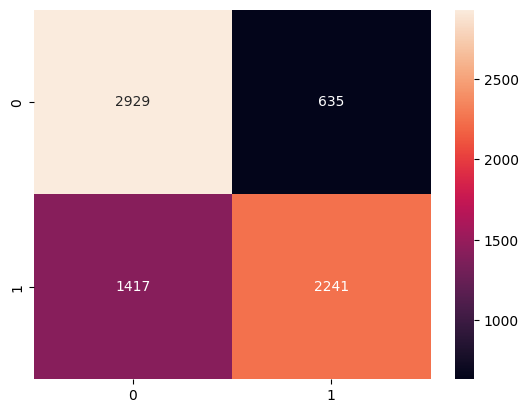

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.82      0.74      3564
           1       0.78      0.61      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.72      0.71      7222
weighted avg       0.73      0.72      0.71      7222



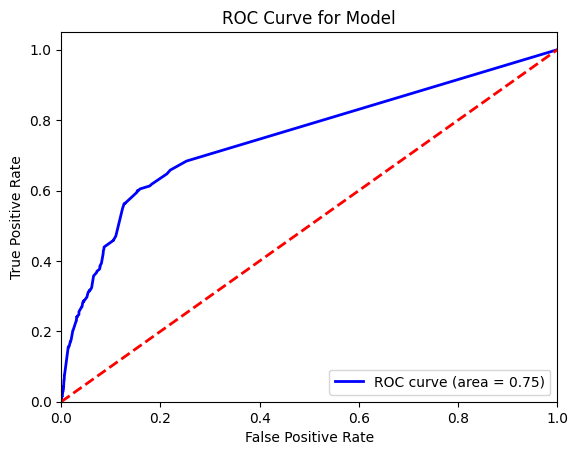

In [5]:
model = Model(layers_dim=[X_train.shape[1], 1], activations=[Sigmoid()])
model.train(X_train, y_train.reshape(-1, 1), num_passes=20000, learning_rate=0.01, print_loss=True)
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to binary predictions
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)
